In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
close_prices = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitcoin_data.csv",
                           index_col=0,
                           parse_dates=True)
close_prices

,open,high,low,close,Volume BTC,Volume USD
date,,,,,,
2024-01-01 00:00:00,42258.0,42268.0,42257,42268,1.049735,44370.180382
2024-01-01 00:01:00,42268.0,42283.0,42268,42283,2.291939,96910.057583
2024-01-01 00:02:00,42288.0,42298.0,42288,42298,1.569998,66407.775404
2024-01-01 00:03:00,42297.0,42353.0,42297,42353,4.883858,206846.034909
2024-01-01 00:04:00,42359.0,42375.0,42359,42375,5.742427,243335.353448
...,...,...,...,...,...,...
2025-02-10 23:39:00,97347.0,97347.0,97339,97339,0.005864,570.787135
2025-02-10 23:40:00,97339.0,97339.0,97336,97336,0.016011,1558.430149
2025-02-10 23:41:00,97340.0,97346.0,97340,97346,0.001320,128.496720


In [3]:
macro_data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/cleaned_Macro.csv",
                               index_col=0,
                               parse_dates=True)
macro_data

,SP500,CPI,Gold,VIX,Oil
date,,,,,
2024-01-01,NaN,NaN,2062.5901,NaN,NaN
2024-01-02,4742.83,NaN,2058.8767,13.20,76.24
2024-01-03,4704.81,NaN,2040.7760,14.04,77.18
2024-01-04,4688.68,NaN,2043.2600,14.13,75.79
2024-01-05,4697.24,NaN,2045.5000,13.35,78.31
...,...,...,...,...,...
2024-12-25,6040.04,315.493,2634.4299,14.27,73.50
2024-12-26,6037.59,315.493,2634.4299,14.73,73.50
2024-12-27,5970.84,315.493,2620.0000,15.95,73.77


In [4]:
# Import fear and greed data 
fear_n_greed = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/fear_n_greed_2024.csv",
                               index_col=0,
                               parse_dates=True)
fear_n_greed.rename(columns = {'value': 'fear_n_greed_index'}, inplace = True)
fear_n_greed = fear_n_greed.drop(columns = ['classification'])
fear_n_greed

,fear_n_greed_index
date,
2024-01-01,65
2024-01-02,71
2024-01-03,70
2024-01-04,68
2024-01-05,72
...,...
2024-12-27,74
2024-12-28,72
2024-12-29,73


In [5]:
# Merge price and sentiment data
df = pd.merge(close_prices, macro_data, on='date', how='outer')
df = pd.merge(df, fear_n_greed, on='date', how='outer')

# Select dates
df = df.loc['2024-01-01 00:00:00':'2024-12-31 23:59:00']

# Display data
df

,open,high,low,close,Volume BTC,Volume USD,SP500,CPI,Gold,VIX,Oil,fear_n_greed_index
date,,,,,,,,,,,,
2024-01-01 00:00:00,42258.0,42268.0,42257.0,42268.0,1.049735,44370.180382,NaN,NaN,2062.5901,NaN,NaN,65.0
2024-01-01 00:01:00,42268.0,42283.0,42268.0,42283.0,2.291939,96910.057583,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:02:00,42288.0,42298.0,42288.0,42298.0,1.569998,66407.775404,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:03:00,42297.0,42353.0,42297.0,42353.0,4.883858,206846.034909,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:04:00,42359.0,42375.0,42359.0,42375.0,5.742427,243335.353448,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471.0,93471.0,0.179799,16805.981112,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 23:56:00,93469.0,93469.0,93469.0,93469.0,0.021400,2000.236600,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 23:57:00,93462.0,93462.0,93413.0,93427.0,0.034750,3246.554616,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.count()

open                  509364
high                  509364
low                   509364
close                 509364
Volume BTC            509364
Volume USD            509364
SP500                    265
CPI                      244
Gold                     266
VIX                      265
Oil                      265
fear_n_greed_index       365
dtype: int64

In [7]:
print(f"The number of data missing: \n{df.isnull().sum()}")

The number of data missing: 
open                      84
high                      84
low                       84
close                     84
Volume BTC                84
Volume USD                84
SP500                 509183
CPI                   509204
Gold                  509182
VIX                   509183
Oil                   509183
fear_n_greed_index    509083
dtype: int64


In [8]:
# Forward-fill missing sentiment scores
df = df.ffill()

# Drop rows with missing data
df = df.dropna()

In [9]:
df

,open,high,low,close,Volume BTC,Volume USD,SP500,CPI,Gold,VIX,Oil,fear_n_greed_index
date,,,,,,,,,,,,
2024-01-31 00:00:00,42945.0,42989.0,42933.0,42984.0,5.160732,221828.915894,4845.65,308.417,2037.1899,14.35,82.98,60.0
2024-01-31 00:01:00,42981.0,43056.0,42981.0,43056.0,7.969300,343126.169175,4845.65,308.417,2037.1899,14.35,82.98,60.0
2024-01-31 00:02:00,43056.0,43098.0,43022.0,43022.0,9.561501,411354.902045,4845.65,308.417,2037.1899,14.35,82.98,60.0
2024-01-31 00:03:00,43019.0,43029.0,43005.0,43005.0,0.598142,25723.117782,4845.65,308.417,2037.1899,14.35,82.98,60.0
2024-01-31 00:04:00,43002.0,43031.0,43002.0,43006.0,0.941927,40508.530194,4845.65,308.417,2037.1899,14.35,82.98,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471.0,93471.0,0.179799,16805.981112,5881.63,315.605,2623.8101,17.35,74.58,64.0
2024-12-31 23:56:00,93469.0,93469.0,93469.0,93469.0,0.021400,2000.236600,5881.63,315.605,2623.8101,17.35,74.58,64.0
2024-12-31 23:57:00,93462.0,93462.0,93413.0,93427.0,0.034750,3246.554616,5881.63,315.605,2623.8101,17.35,74.58,64.0


In [10]:
df.count()

open                  468137
high                  468137
low                   468137
close                 468137
Volume BTC            468137
Volume USD            468137
SP500                 468137
CPI                   468137
Gold                  468137
VIX                   468137
Oil                   468137
fear_n_greed_index    468137
dtype: int64

In [11]:
df.isna().sum()

open                  0
high                  0
low                   0
close                 0
Volume BTC            0
Volume USD            0
SP500                 0
CPI                   0
Gold                  0
VIX                   0
Oil                   0
fear_n_greed_index    0
dtype: int64

In [12]:
# Correlation matrix
df.corr()

,open,high,low,close,Volume BTC,Volume USD,SP500,CPI,Gold,VIX,Oil,fear_n_greed_index
open,1.000000,0.999997,0.999996,0.999994,0.031274,0.093527,0.691669,0.519241,0.552114,-0.038467,-0.459338,0.505758
high,0.999997,1.000000,0.999993,0.999997,0.032070,0.094315,0.691507,0.519079,0.551950,-0.038287,-0.459198,0.505815
low,0.999996,0.999993,1.000000,0.999997,0.030293,0.092548,0.691848,0.519410,0.552301,-0.038642,-0.459503,0.505678
close,0.999994,0.999997,0.999997,1.000000,0.031181,0.093434,0.691679,0.519239,0.552126,-0.038473,-0.459357,0.505752
Volume BTC,0.031274,0.032070,0.030293,0.031181,1.000000,0.977257,0.009049,-0.002757,-0.000878,0.029224,-0.009241,0.021585
Volume USD,0.093527,0.094315,0.092548,0.093434,0.977257,1.000000,0.054817,0.030007,0.034536,0.021091,-0.040497,0.055733
SP500,0.691669,0.691507,0.691848,0.691679,0.009049,0.054817,1.000000,0.822527,0.883975,0.180803,-0.718503,-0.018572
CPI,0.519241,0.519079,0.519410,0.519239,-0.002757,0.030007,0.822527,1.000000,0.912205,0.331414,-0.588436,-0.252406
Gold,0.552114,0.551950,0.552301,0.552126,-0.000878,0.034536,0.883975,0.912205,1.000000,0.426550,-0.689930,-0.132277
VIX,-0.038467,-0.038287,-0.038642,-0.038473,0.029224,0.021091,0.180803,0.331414,0.426550,1.000000,-0.332218,-0.303945


In [13]:
# Compute correlation matrix
df[['close', 'Volume USD', 'SP500', 'CPI', 'Gold', 'VIX', 'Oil', 'fear_n_greed_index']].corr()

,close,Volume USD,SP500,CPI,Gold,VIX,Oil,fear_n_greed_index
close,1.000000,0.093434,0.691679,0.519239,0.552126,-0.038473,-0.459357,0.505752
Volume USD,0.093434,1.000000,0.054817,0.030007,0.034536,0.021091,-0.040497,0.055733
SP500,0.691679,0.054817,1.000000,0.822527,0.883975,0.180803,-0.718503,-0.018572
CPI,0.519239,0.030007,0.822527,1.000000,0.912205,0.331414,-0.588436,-0.252406
Gold,0.552126,0.034536,0.883975,0.912205,1.000000,0.426550,-0.689930,-0.132277
VIX,-0.038473,0.021091,0.180803,0.331414,0.426550,1.000000,-0.332218,-0.303945
Oil,-0.459357,-0.040497,-0.718503,-0.588436,-0.689930,-0.332218,1.000000,-0.017627
fear_n_greed_index,0.505752,0.055733,-0.018572,-0.252406,-0.132277,-0.303945,-0.017627,1.000000


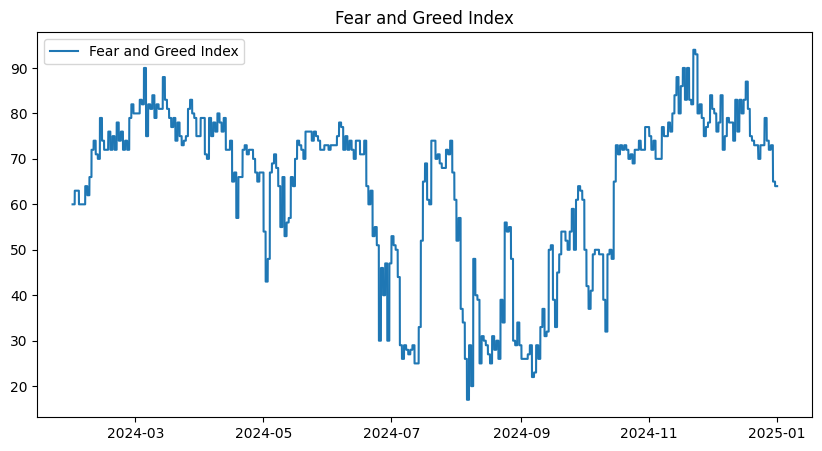

In [14]:
# Plot fear_n_greed_index
plt.figure(figsize=(10, 5))
plt.plot(df['fear_n_greed_index'], label='Fear and Greed Index')
plt.title('Fear and Greed Index')
plt.legend(loc='best')
plt.show()

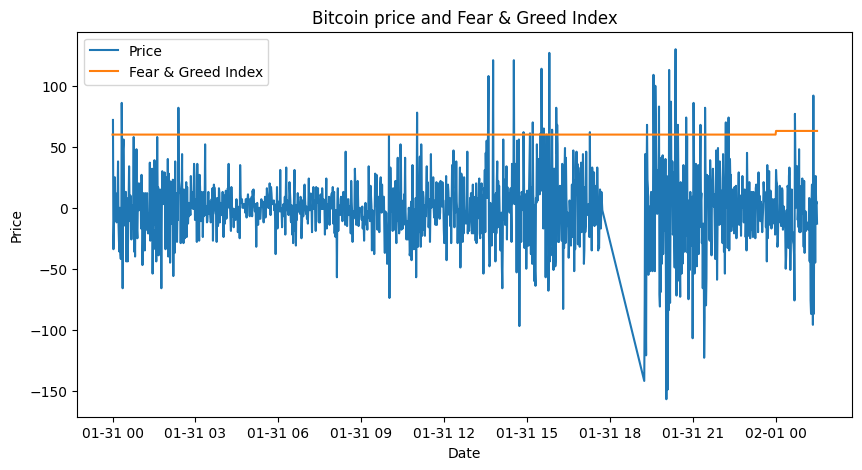

In [15]:
# Plot fear_n_greed index and Bitcoin price diff in one graph to see if there is any correlation
diff = df['close'].diff()

plt.figure(figsize=(10, 5))
plt.plot(diff[:1440])
plt.plot(df['fear_n_greed_index'][:1440])
plt.title('Bitcoin price and Fear & Greed Index')
plt.ylabel('Price')
plt.xlabel('Date')
plt.legend(['Price', 'Fear & Greed Index'])
plt.show()

In [16]:
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitcoin_data_full.csv")